# 05 - Análise dos Clusters

O notebook 04 definiu os três grupos. Agora o objetivo é entender o que cada um representa na
prática e dar um nome a cada grupo que faça sentido para quem for ler o relatório, em vez de
só "cluster 0, 1, 2".

In [1]:
import sys
sys.path.append('..')

import json
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import umap

from src.preprocessing import TODAS_AS_FEATURES, dataframe_padronizado
from src.visualization import configurar_estilo, plot_umap_clusters

configurar_estilo()

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('../data/processed/paises_clusterizados.csv')
df[['pais', 'cluster'] + TODAS_AS_FEATURES].head()

,pais,cluster,mortalidade_infantil,exportacoes,saude,importacoes,renda,inflacao,expectativa_vida,fertilidade_total,pib_per_capita
0,Afghanistan,2,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,0,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,0,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,2,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,0,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Perfil de cada grupo

In [3]:
perfil = df.groupby('cluster')[TODAS_AS_FEATURES].mean().round(1)
perfil

,mortalidade_infantil,exportacoes,saude,importacoes,renda,inflacao,expectativa_vida,fertilidade_total,pib_per_capita
cluster,,,,,,,,,
0,21.2,41.7,6.1,47.3,14815.4,7.7,73.1,2.3,7825.4
1,4.4,57.5,9.6,52.7,43848.4,1.5,80.5,1.7,44458.1
2,93.0,29.2,6.4,42.3,3942.4,12.0,59.2,5.0,1922.4


In [4]:
# Nomeando os clusters pelo PIB per capita médio
ordem_por_renda = perfil['pib_per_capita'].sort_values().index.tolist()
nomes_cluster = {
    ordem_por_renda[0]: 'Menos desenvolvido',
    ordem_por_renda[1]: 'Em desenvolvimento',
    ordem_por_renda[2]: 'Desenvolvido',
}
nomes_cluster

{2: 'Menos desenvolvido', 0: 'Em desenvolvimento', 1: 'Desenvolvido'}

In [5]:
perfil_nomeado = perfil.copy()
perfil_nomeado.index = perfil_nomeado.index.map(nomes_cluster)
perfil_nomeado = perfil_nomeado.loc[['Desenvolvido', 'Em desenvolvimento', 'Menos desenvolvido']]
perfil_nomeado.T

cluster,Desenvolvido,Em desenvolvimento,Menos desenvolvido
mortalidade_infantil,4.4,21.2,93.0
exportacoes,57.5,41.7,29.2
saude,9.6,6.1,6.4
importacoes,52.7,47.3,42.3
renda,43848.4,14815.4,3942.4
inflacao,1.5,7.7,12.0
expectativa_vida,80.5,73.1,59.2
fertilidade_total,1.7,2.3,5.0
pib_per_capita,44458.1,7825.4,1922.4


In [6]:
contagem = df['cluster'].map(nomes_cluster).value_counts()
contagem = contagem.loc[['Desenvolvido', 'Em desenvolvimento', 'Menos desenvolvido']]
contagem.rename('nº de países')

cluster
Desenvolvido          31
Em desenvolvimento    89
Menos desenvolvido    47
Name: nº de países, dtype: int64

## Visualizando os grupos

Os dados têm 8 dimensões (as features escolhidas no notebook 03). Para visualizar a separação em 2D, testei PCA e UMAP: o UMAP separou os três grupos de forma bem mais nítida, então fico só com ele aqui. Os clusters em si continuam vindo do K-Means nas variáveis originais, o UMAP é usado só para visualização.

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


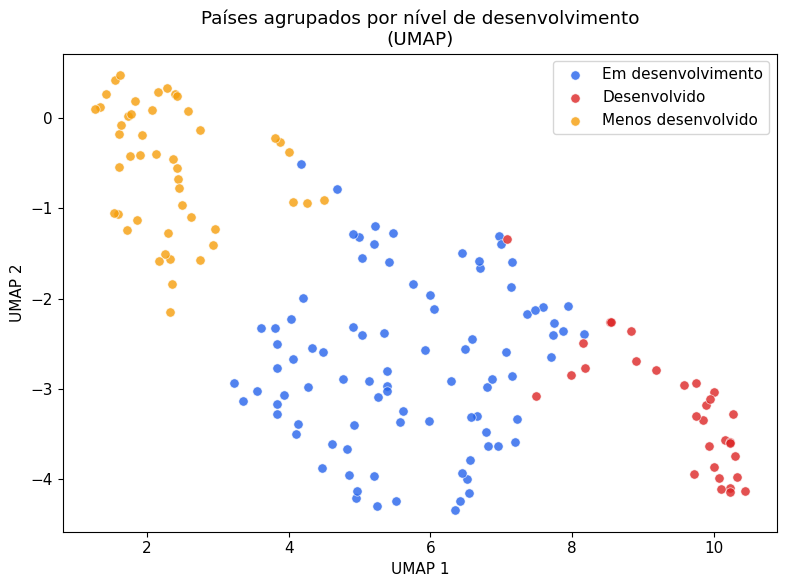

In [7]:
with open('../data/processed/features_selecionadas.json') as f:
    features = json.load(f)

X_escalado_df, _ = dataframe_padronizado(df, features)
X_escalado = X_escalado_df[features].values

reducer = umap.UMAP(n_components=2, random_state=42)
coords_umap = reducer.fit_transform(X_escalado)

plot_umap_clusters(coords_umap, df['cluster'].values, nomes_cluster)
plt.show()

## Comparando os indicadores de saúde e demografia

In [8]:


indicadores_chave = [
    'mortalidade_infantil',
    'expectativa_vida',
    'fertilidade_total',
    'saude'
]

perfil_chave = df.groupby('cluster')[indicadores_chave].mean()

perfil_chave.index = perfil_chave.index.map(nomes_cluster)

perfil_chave = perfil_chave.loc[
    ['Desenvolvido', 'Em desenvolvimento', 'Menos desenvolvido']
]


perfil_plot = perfil_chave.reset_index().melt(
    id_vars='cluster',
    var_name='Indicador',
    value_name='Média'
)

fig = px.bar(
    perfil_plot,
    x='cluster',
    y='Média',
    color='Indicador',
    barmode='group',
    text='Média',
    title='Indicadores de saúde e demografia por grupo'
)

fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Grupo',
    yaxis_title='Média',
    legend_title='Indicador',
    template='plotly_white',
    height=550,
    bargap=0.2
)

fig.show()

## O que cada grupo representa

- **Desenvolvido** (31 países): mortalidade infantil baixíssima (cerca de 4 a cada mil nascidos), renda alta, expectativa de vida em torno de 80 anos. Noruega, Alemanha e Japão caem aqui.
- **Em desenvolvimento** (89 países): a maior parte do mundo, com indicadores intermediários. Brasil, México e China estão neste grupo.
- **Menos desenvolvido** (47 países): mortalidade infantil de cerca de 93 a cada mil crianças, mais de 20 vezes maior que no grupo desenvolvido, renda média abaixo de 4 mil dólares por ano e expectativa de vida cerca de 21 anos menor. É este o grupo que mais precisa de atenção.

## Salvando o perfil

In [9]:
perfil_nomeado.to_csv('../data/processed/perfil_clusters.csv')
print("Salvo em data/processed/perfil_clusters.csv")

Salvo em data/processed/perfil_clusters.csv
